In [1]:
from mlxtend.frequent_patterns import apriori
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd
import numpy as np
from itertools import combinations
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

## Etape 1

### Prétraitement et Binarisation

In [2]:
# Chargement et préparation des données
#transactions = pd.read_csv('../2-Sampling/datasets/sample_transactions.csv', header=None)
transactions = pd.read_csv('sample_transactions.csv', header=None)
transactions.drop([0], inplace=True)
transactions = transactions.groupby(0)[1].apply(lambda x: ' '.join(x)).reset_index()
transactions.drop(0, axis=1, inplace=True)

# Binarisation avec TransactionEncoder
transactions_list = transactions[1].apply(lambda x: x.split()).tolist()
te = TransactionEncoder()
te_ary = te.fit(transactions_list).transform(transactions_list)
df = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Dataset binarisé : {df.shape[0]} transactions, {df.shape[1]} items")
print(f"Densité moyenne : {df.mean().mean():.2%}\n")

Dataset binarisé : 500 transactions, 20 items
Densité moyenne : 17.78%



### Extraction

In [3]:
# Utiliser un seuil très bas pour obtenir un pool exhaustif
MIN_SUPPORT = 0.005  # 0.5% 

frequent_itemsets = apriori(df, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

print(f"Pool P : {len(frequent_itemsets)} motifs extraits avec min_support={MIN_SUPPORT}")
print(f"Distribution des longueurs :")
print(frequent_itemsets['length'].value_counts().sort_index())

Pool P : 818 motifs extraits avec min_support=0.005
Distribution des longueurs :
length
1     20
2    190
3    557
4     51
Name: count, dtype: int64


### Calcul des métriques

In [4]:
# 3.1 Support : déjà calculé par Apriori
# 3.2 Longueur : déjà calculée
# 3.3 Couverture (coverage) : proportion de transactions contenant le motif
def calc_coverage(itemset, df):
    """Calcule la couverture réelle d'un itemset"""
    mask = df[list(itemset)].all(axis=1)
    return mask.sum() / len(df)

frequent_itemsets['coverage'] = frequent_itemsets['itemsets'].apply(
    lambda x: calc_coverage(x, df)
)

# 3.4 Confidence et Lift pour TOUS les motifs (pas seulement les paires)
def calc_all_metrics(frequent_itemsets, df):
    """
    Calcule confidence et lift pour tous les sous-ensembles possibles
    de chaque motif (règles d'association)
    """
    supports_dict = dict(zip(frequent_itemsets['itemsets'], frequent_itemsets['support']))
    
    metrics_list = []
    
    for idx, row in frequent_itemsets.iterrows():
        itemset = row['itemsets']
        support_xy = row['support']
        length = len(itemset)
        
        # Pour les singletons : pas de confidence/lift
        if length == 1:
            metrics_list.append({
                'itemset': itemset,
                'support': support_xy,
                'coverage': row['coverage'],
                'length': length,
                'confidence': np.nan,
                'lift': np.nan,
                'antecedent': None,
                'consequent': None
            })
        else:
            # Générer toutes les règles possibles X -> Y
            best_conf = 0
            best_lift = 0
            best_ante = None
            best_cons = None
            
            for i in range(1, length):
                for antecedent in combinations(itemset, i):
                    antecedent = frozenset(antecedent)
                    consequent = itemset - antecedent
                    
                    if antecedent in supports_dict and consequent in supports_dict:
                        support_x = supports_dict[antecedent]
                        support_y = supports_dict[consequent]
                        
                        confidence = support_xy / support_x
                        lift = support_xy / (support_x * support_y)
                        
                        # Garder la meilleure règle
                        if confidence > best_conf:
                            best_conf = confidence
                            best_lift = lift
                            best_ante = antecedent
                            best_cons = consequent
            
            metrics_list.append({
                'itemset': itemset,
                'support': support_xy,
                'coverage': row['coverage'],
                'length': length,
                'confidence': best_conf if best_conf > 0 else np.nan,
                'lift': best_lift if best_lift > 0 else np.nan,
                'antecedent': best_ante,
                'consequent': best_cons
            })
    
    return pd.DataFrame(metrics_list)

# Calculer toutes les métriques
pool_P = calc_all_metrics(frequent_itemsets, df)

### Résultats

In [5]:
print("="*70)
print("POOL DE CANDIDATS P - Métriques complètes")
print("="*70)

# Statistiques globales
print(f"\nNombre total de motifs : {len(pool_P)}")
print(f"Support moyen : {pool_P['support'].mean():.4f}")
print(f"Coverage moyenne : {pool_P['coverage'].mean():.4f}")
print(f"Longueur moyenne : {pool_P['length'].mean():.2f}")

# Top motifs par support
print("\n--- Top 10 motifs par support ---")
top_support = pool_P.nlargest(10, 'support')[['itemset', 'support', 'coverage', 'length']]
print(top_support.to_string(index=False))

# Top motifs par confidence (excluant singletons)
print("\n--- Top 10 motifs par confidence ---")
top_conf = pool_P[pool_P['length'] > 1].nlargest(10, 'confidence')[
    ['itemset', 'confidence', 'lift', 'support', 'length']
]
print(top_conf.to_string(index=False))

# Top motifs par lift
print("\n--- Top 10 motifs par lift ---")
top_lift = pool_P[pool_P['length'] > 1].nlargest(10, 'lift')[
    ['itemset', 'lift', 'confidence', 'support', 'length']
]
print(top_lift.to_string(index=False))

# Distribution des métriques
print("\n--- Statistiques descriptives ---")
print(pool_P[['support', 'coverage', 'confidence', 'lift', 'length']].describe())

# Sauvegarde du pool P
pool_P.to_csv('pool_P_candidats.csv', index=False)
print("\n✅ Pool P sauvegardé dans 'pool_P_candidats.csv'")

POOL DE CANDIDATS P - Métriques complètes

Nombre total de motifs : 818
Support moyen : 0.0175
Coverage moyenne : 0.0175
Longueur moyenne : 2.78

--- Top 10 motifs par support ---
  itemset  support  coverage  length
  (pasta)    0.210     0.210       1
 (butter)    0.200     0.200       1
(lettuce)    0.200     0.200       1
 (coffee)    0.198     0.198       1
    (tea)    0.198     0.198       1
  (onion)    0.190     0.190       1
   (rice)    0.190     0.190       1
 (cereal)    0.186     0.186       1
   (salt)    0.182     0.182       1
  (sugar)    0.182     0.182       1

--- Top 10 motifs par confidence ---
                          itemset  confidence     lift  support  length
    (salt, cereal, apple, butter)         1.0 5.000000    0.006       4
    (yogurt, rice, apple, cheese)         1.0 7.575758    0.006       4
   (lettuce, coffee, apple, rice)         1.0 5.000000    0.006       4
      (pasta, apple, tomato, tea)         1.0 6.329114    0.006       4
(cheese, lettuc

## Etape 2

### Stratégie de scoring

In [6]:
class ScoringStrategy:
    """Classe de base pour les stratégies de scoring"""
    
    def __init__(self, pool_P):
        self.pool_P = pool_P.copy()
        self._normalize_metrics()
        self._compute_redundancy()
    
    def _normalize_metrics(self):
        """Normalise les métriques entre 0 et 1"""
        metrics = ['support', 'coverage', 'confidence', 'lift']
        
        for metric in metrics:
            if metric in self.pool_P.columns:
                values = self.pool_P[metric].fillna(0)
                if values.max() > values.min():
                    self.pool_P[f'{metric}_norm'] = (values - values.min()) / (values.max() - values.min())
                else:
                    self.pool_P[f'{metric}_norm'] = 0.5
    
    def _compute_redundancy(self):
        """Calcule la redondance via similarité de Jaccard"""
        n = len(self.pool_P)
        itemsets_list = self.pool_P['itemset'].tolist()
        
        # Matrice de similarité
        similarity_matrix = np.zeros((n, n))
        for i in range(n):
            for j in range(i+1, n):
                set_i = itemsets_list[i]
                set_j = itemsets_list[j]
                intersection = len(set_i & set_j)
                union = len(set_i | set_j)
                similarity = intersection / union if union > 0 else 0
                similarity_matrix[i, j] = similarity
                similarity_matrix[j, i] = similarity
        
        # Redondance moyenne pour chaque motif
        self.pool_P['redundancy'] = similarity_matrix.mean(axis=1)
    
    def compute_score(self):
        """Méthode abstraite à implémenter par les sous-classes"""
        raise NotImplementedError


class BalancedScoring(ScoringStrategy):
    """Scoring équilibré : support + lift + surprise - redondance"""
    
    def compute_score(self):
        # Surprise = confidence * (1 - support)
        self.pool_P['surprise'] = self.pool_P['confidence'].fillna(0) * (1 - self.pool_P['support_norm'])
        self.pool_P['surprise_norm'] = (self.pool_P['surprise'] - self.pool_P['surprise'].min()) / \
                                        (self.pool_P['surprise'].max() - self.pool_P['surprise'].min() + 1e-10)
        
        # Score composite
        self.pool_P['score'] = (
            0.3 * self.pool_P['support_norm'] +
            0.3 * self.pool_P['lift_norm'].fillna(0) +
            0.3 * self.pool_P['surprise_norm'] -
            0.1 * self.pool_P['redundancy']
        )
        
        return self.pool_P


class QualityScoring(ScoringStrategy):
    """Scoring qualité : priorité à lift, confidence et longueur"""
    
    def compute_score(self):
        # Normaliser longueur
        self.pool_P['length_norm'] = self.pool_P['length'] / self.pool_P['length'].max()
        
        # Score composite
        self.pool_P['score'] = (
            0.4 * self.pool_P['lift_norm'].fillna(0) +
            0.3 * self.pool_P['confidence_norm'].fillna(0) +
            0.2 * self.pool_P['length_norm'] -
            0.1 * self.pool_P['redundancy']
        )
        
        return self.pool_P


class DiversityScoring(ScoringStrategy):
    """Scoring diversité : favorise les motifs peu redondants"""
    
    def compute_score(self):
        # Score composite
        self.pool_P['score'] = (
            0.25 * self.pool_P['support_norm'] +
            0.25 * self.pool_P['confidence_norm'].fillna(0) +
            0.25 * self.pool_P['lift_norm'].fillna(0) -
            0.25 * self.pool_P['redundancy']
        )
        
        return self.pool_P

### Algorithmes d'échantionnage

In [7]:
class InteractiveSampler:
    """Échantillonneur interactif avec feedback utilisateur"""
    
    def __init__(self, pool_P, strategy='balanced'):
        self.pool_P_original = pool_P.copy()
        self.strategy_name = strategy
        self.feedback_history = []
        self.user_weights = np.ones(len(pool_P))
        
        # Appliquer la stratégie de scoring
        self._apply_scoring_strategy()
    
    def _apply_scoring_strategy(self):
        """Applique la stratégie de scoring choisie"""
        strategies = {
            'balanced': BalancedScoring,
            'quality': QualityScoring,
            'diversity': DiversityScoring
        }
        
        if self.strategy_name not in strategies:
            raise ValueError(f"Stratégie inconnue : {self.strategy_name}")
        
        strategy = strategies[self.strategy_name](self.pool_P_original)
        self.pool_P = strategy.compute_score()
    
    def importance_sampling(self, k=10, with_replacement=False, temperature=1.0):
        """
        Échantillonnage par importance pondéré
        
        Args:
            k: nombre de motifs à échantillonner
            with_replacement: remise ou non
            temperature: contrôle la "concentration" (plus petit = plus concentré)
        """
        # Calcul des poids finaux (score * feedback utilisateur)
        final_scores = self.pool_P['score'] * self.user_weights
        
        # Éviter les scores négatifs
        final_scores = final_scores - final_scores.min() + 1e-10
        
        # Appliquer la température
        probabilities = np.power(final_scores, 1/temperature)
        probabilities = probabilities / probabilities.sum()
        
        # Échantillonnage
        if with_replacement:
            indices = np.random.choice(
                len(self.pool_P), 
                size=k, 
                replace=True, 
                p=probabilities
            )
        else:
            indices = np.random.choice(
                len(self.pool_P), 
                size=min(k, len(self.pool_P)), 
                replace=False, 
                p=probabilities
            )
        
        sampled = self.pool_P.iloc[indices].copy()
        sampled['sampling_prob'] = probabilities[indices]
        sampled['sample_id'] = range(len(sampled))
        
        return sampled
    
    def mcmc_sampling(self, k=10, n_iterations=1000, temperature=1.0):
        """
        Échantillonnage MCMC léger (Metropolis-Hastings)
        
        Args:
            k: nombre de motifs à échantillonner
            n_iterations: nombre d'itérations MCMC
            temperature: contrôle l'exploration
        """
        final_scores = self.pool_P['score'] * self.user_weights
        final_scores = final_scores - final_scores.min() + 1e-10
        
        n_patterns = len(self.pool_P)
        sampled_indices = []
        
        # Initialisation aléatoire
        current_idx = np.random.randint(n_patterns)
        current_score = final_scores.iloc[current_idx]
        
        for _ in range(n_iterations):
            # Proposer un nouveau motif
            proposed_idx = np.random.randint(n_patterns)
            proposed_score = final_scores.iloc[proposed_idx]
            
            # Calcul du ratio d'acceptation
            acceptance_ratio = min(1, np.exp((proposed_score - current_score) / temperature))
            
            # Accepter ou rejeter
            if np.random.random() < acceptance_ratio:
                current_idx = proposed_idx
                current_score = proposed_score
            
            sampled_indices.append(current_idx)
        
        # Prendre les k derniers (après burn-in)
        burn_in = n_iterations // 2
        final_indices = sampled_indices[burn_in:]
        
        # Échantillonner uniformément parmi les indices collectés
        selected_indices = np.random.choice(final_indices, size=min(k, len(final_indices)), replace=False)
        
        sampled = self.pool_P.iloc[selected_indices].copy()
        sampled['sample_id'] = range(len(sampled))
        
        return sampled
    
    def add_feedback(self, sample_id, feedback):
        """
        Ajoute un feedback utilisateur
        
        Args:
            sample_id: ID du motif dans l'échantillon
            feedback: 'like' (+1) ou 'dislike' (-1)
        """
        if feedback not in ['like', 'dislike']:
            raise ValueError("Feedback doit être 'like' ou 'dislike'")
        
        # Enregistrer le feedback
        self.feedback_history.append({
            'sample_id': sample_id,
            'feedback': feedback,
            'timestamp': len(self.feedback_history)
        })
        
        # Ajuster les poids
        feedback_value = 1.5 if feedback == 'like' else 0.5
        
        # Trouver l'index dans pool_P
        # On ajuste les motifs similaires
        target_itemset = self.pool_P.iloc[sample_id]['itemset']
        
        for idx, row in self.pool_P.iterrows():
            itemset = row['itemset']
            similarity = len(target_itemset & itemset) / len(target_itemset | itemset)
            
            if similarity > 0.5:  # Ajuster les motifs similaires
                self.user_weights[idx] *= (1 + (feedback_value - 1) * similarity)
        
        # Normaliser les poids
        self.user_weights = self.user_weights / self.user_weights.sum() * len(self.user_weights)
    
    def get_feedback_summary(self):
        """Résumé des feedbacks utilisateur"""
        if not self.feedback_history:
            return "Aucun feedback enregistré"
        
        df_feedback = pd.DataFrame(self.feedback_history)
        likes = (df_feedback['feedback'] == 'like').sum()
        dislikes = (df_feedback['feedback'] == 'dislike').sum()
        
        return f"Feedbacks : {likes} likes, {dislikes} dislikes (total: {len(df_feedback)})"


🎲 ÉCHANTILLONNAGE EN SORTIE DE MOTIFS

Nombre de motifs échantillonnés : 200
                    itemset  support      lift  length  sampling_prob
975  (cheese, cereal, eggs)    0.010  1.697078       3       0.001719
257           (sugar, salt)    0.028  0.845309       2       0.000856
924   (yogurt, butter, tea)    0.010  1.387501       3       0.001405
622                (tomato)    0.158  1.000000       1       0.001013
304   (bread, cereal, salt)    0.010  1.697721       3       0.001719
541      (lettuce, chicken)    0.030  0.903614       2       0.000915
184     (sugar, salt, beef)    0.008  1.548184       3       0.001568
151                  (salt)    0.182  1.000000       1       0.001013
767               (chicken)    0.166  1.000000       1       0.001013
668   (cheese, rice, apple)    0.012  2.658161       3       0.002692


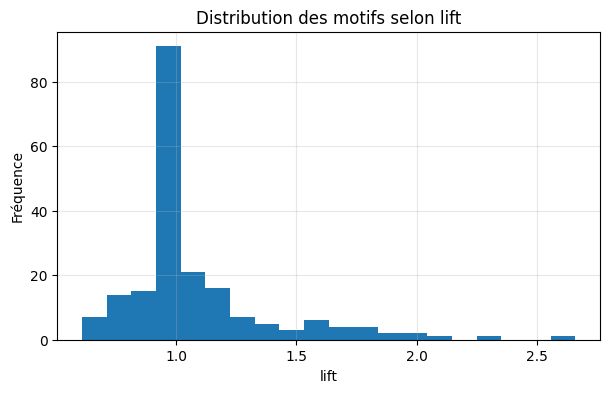

In [8]:
# ============================================================
# 5. ÉCHANTILLONNAGE EN SORTIE DE MOTIFS
# ============================================================

class OutputPatternSampler:
    """
    Échantillonneur de motifs en sortie : génère un échantillon de motifs
    sans fouille exhaustive, en se basant sur une mesure d'intérêt.
    """

    def __init__(self, df_binary, measure='support', n_samples=1000, max_length=3, random_state=None):
        """
        Args:
            df_binary : DataFrame binaire (transactions x items)
            measure : mesure d'intérêt ('support', 'lift', 'length')
            n_samples : nombre de motifs à échantillonner
            max_length : taille max des itemsets
            random_state : graine aléatoire
        """
        self.df = df_binary
        self.measure = measure
        self.n_samples = n_samples
        self.max_length = max_length
        self.rng = np.random.default_rng(random_state)
        self.item_names = list(df_binary.columns)

    def _calc_support(self, itemset):
        """Support = fréquence d'apparition du motif."""
        mask = self.df[list(itemset)].all(axis=1)
        return mask.mean()

    def _calc_lift(self, itemset):
        """Approximation du lift : support(itemset) / prod(supports singletons)."""
        if len(itemset) < 2:
            return 1.0
        support_xy = self._calc_support(itemset)
        support_prod = np.prod([self._calc_support([i]) for i in itemset])
        return support_xy / support_prod if support_prod > 0 else np.nan

    def _sample_itemset(self):
        """Génère un itemset aléatoire (1 à max_length)."""
        length = self.rng.integers(1, self.max_length + 1)
        return frozenset(self.rng.choice(self.item_names, size=length, replace=False))

    def generate_sample(self):
        """Génère un échantillon de motifs selon la mesure d'intérêt."""
        motifs = []
        for _ in range(self.n_samples):
            itemset = self._sample_itemset()
            support = self._calc_support(itemset)
            lift = self._calc_lift(itemset)
            length = len(itemset)

            motifs.append({
                'itemset': itemset,
                'support': support,
                'lift': lift,
                'length': length
            })

        df_motifs = pd.DataFrame(motifs)

        # Pondération selon la mesure choisie
        if self.measure == 'support':
            probs = df_motifs['support'] / df_motifs['support'].sum()
        elif self.measure == 'lift':
            df_motifs['lift'] = df_motifs['lift'].replace([np.inf, np.nan], 0)
            probs = df_motifs['lift'] / (df_motifs['lift'].sum() + 1e-10)
        elif self.measure == 'length':
            probs = df_motifs['length'] / df_motifs['length'].sum()
        else:
            raise ValueError("Mesure inconnue : choisissez 'support', 'lift' ou 'length'")

        # Échantillonner selon la distribution
        sampled_indices = self.rng.choice(
            len(df_motifs), size=min(200, len(df_motifs)), replace=False, p=probs / probs.sum()
        )
        sampled = df_motifs.iloc[sampled_indices].copy()
        sampled['sampling_prob'] = probs.iloc[sampled_indices]

        return sampled

    def plot_distribution(self, df_sampled):
        """Affiche la distribution de la mesure d'intérêt dans l'échantillon."""
        import matplotlib.pyplot as plt
        plt.figure(figsize=(7, 4))
        plt.hist(df_sampled[self.measure], bins=20)
        plt.title(f"Distribution des motifs selon {self.measure}")
        plt.xlabel(self.measure)
        plt.ylabel("Fréquence")
        plt.grid(alpha=0.3)
        plt.show()

# ============================================================
# 6. ÉCHANTILLONNAGE EN SORTIE DE MOTIFS (Step 5)
# # ============================================================
if __name__ == "__main__":
    print("\n🎲 ÉCHANTILLONNAGE EN SORTIE DE MOTIFS")
    out_sampler = OutputPatternSampler(df, measure='lift', n_samples=1000, max_length=3)
    sampled_motifs = out_sampler.generate_sample()

    print(f"\nNombre de motifs échantillonnés : {len(sampled_motifs)}")
    print(sampled_motifs.head(10))

    # Afficher la distribution des motifs selon la mesure choisie
    out_sampler.plot_distribution(sampled_motifs)

In [9]:
# ============================================================
# 3. INTERFACE INTERACTIVE
# ============================================================

class InteractivePatternMining:
    """Interface complète pour l'exploration interactive de motifs"""
    
    def __init__(self, pool_P_path='pool_P_candidats.csv'):
        # Charger le pool P
        self.pool_P = pd.read_csv(pool_P_path)
        self.pool_P['itemset'] = self.pool_P['itemset'].apply(eval)
        
        self.sampler = None
        self.current_sample = None
    
    def start_session(self, strategy='balanced', method='importance', k=10, **kwargs):
        """
        Démarre une session d'exploration interactive
        
        Args:
            strategy: 'balanced', 'quality', ou 'diversity'
            method: 'importance' ou 'mcmc'
            k: nombre de motifs à échantillonner
            **kwargs: paramètres additionnels (temperature, with_replacement, etc.)
        """
        print("="*70)
        print(f"SESSION D'EXPLORATION INTERACTIVE")
        print("="*70)
        print(f"Stratégie de scoring : {strategy}")
        print(f"Méthode d'échantillonnage : {method}")
        print(f"Taille de l'échantillon : {k}")
        print()
        
        # Initialiser le sampler
        self.sampler = InteractiveSampler(self.pool_P, strategy=strategy)
        
        # Échantillonner
        if method == 'importance':
            self.current_sample = self.sampler.importance_sampling(k=k, **kwargs)
        elif method == 'mcmc':
            self.current_sample = self.sampler.mcmc_sampling(k=k, **kwargs)
        else:
            raise ValueError(f"Méthode inconnue : {method}")
        
        self._display_sample()
    
    def _display_sample(self):
        """Affiche l'échantillon courant"""
        print("MOTIFS ÉCHANTILLONNÉS :")
        print("-" * 70)
        
        for idx, row in self.current_sample.iterrows():
            sample_id = row['sample_id']
            itemset = row['itemset']
            score = row['score']
            support = row['support']
            confidence = row.get('confidence', np.nan)
            lift = row.get('lift', np.nan)
            
            print(f"[{sample_id}] {itemset}")
            print(f"    Score: {score:.4f} | Support: {support:.4f} | "
                  f"Confidence: {confidence:.4f} | Lift: {lift:.4f}")
            print()
    
    def feedback(self, sample_id, feedback_type):
        """Enregistre un feedback utilisateur"""
        if self.sampler is None:
            print("❌ Aucune session active. Utilisez start_session() d'abord.")
            return
        
        self.sampler.add_feedback(sample_id, feedback_type)
        print(f"✅ Feedback '{feedback_type}' enregistré pour le motif {sample_id}")
        print(self.sampler.get_feedback_summary())
    
    def resample(self, k=None):
        """Ré-échantillonne avec les poids mis à jour"""
        if self.sampler is None:
            print("❌ Aucune session active. Utilisez start_session() d'abord.")
            return
        
        if k is None:
            k = len(self.current_sample)
        
        print("\n" + "="*70)
        print("RÉ-ÉCHANTILLONNAGE (avec feedbacks intégrés)")
        print("="*70)
        
        self.current_sample = self.sampler.importance_sampling(k=k)
        self._display_sample()
    
    def compare_strategies(self, k=10):
        """Compare les différentes stratégies de scoring"""
        strategies = ['balanced', 'quality', 'diversity']
        
        print("="*70)
        print("COMPARAISON DES STRATÉGIES")
        print("="*70)
        
        for strategy in strategies:
            print(f"\n--- Stratégie : {strategy.upper()} ---")
            sampler = InteractiveSampler(self.pool_P, strategy=strategy)
            sample = sampler.importance_sampling(k=k, temperature=1.0)
            
            print(f"Score moyen : {sample['score'].mean():.4f}")
            print(f"Support moyen : {sample['support'].mean():.4f}")
            print(f"Lift moyen : {sample['lift'].fillna(0).mean():.4f}")
            print(f"Longueur moyenne : {sample['length'].mean():.2f}")


# ============================================================
# 4. EXEMPLE D'UTILISATION
# ============================================================

if __name__ == "__main__":
    # Initialiser l'interface
    ipm = InteractivePatternMining('pool_P_candidats.csv')
    
    # Démarrer une session avec stratégie balanced
    print("\n🔍 SESSION 1 : Stratégie Balanced")
    ipm.start_session(strategy='balanced', method='importance', k=10, temperature=1.0)
    
    # Simuler des feedbacks utilisateur
    print("\n💬 FEEDBACKS UTILISATEUR")
    ipm.feedback(0, 'like')
    ipm.feedback(1, 'like')
    ipm.feedback(5, 'dislike')
    
    # Ré-échantillonner avec feedbacks
    print("\n🔄 RÉ-ÉCHANTILLONNAGE")
    ipm.resample(k=10)
    
    # Comparer les stratégies
    print("\n📊 COMPARAISON DES STRATÉGIES")
    ipm.compare_strategies(k=10)
    
    # Session avec MCMC
    print("\n🔍 SESSION 2 : Méthode MCMC")
    ipm.start_session(strategy='quality', method='mcmc', k=10, n_iterations=1000)

    # Simuler des feedbacks utilisateur
    print("\n💬 FEEDBACKS UTILISATEUR")
    ipm.feedback(0, 'like')
    ipm.feedback(1, 'like')
    ipm.feedback(5, 'dislike')
    
    # Ré-échantillonner avec feedbacks
    print("\n🔄 RÉ-ÉCHANTILLONNAGE")
    ipm.resample(k=10)
    
    # Comparer les stratégies
    print("\n📊 COMPARAISON DES STRATÉGIES")
    ipm.compare_strategies(k=10)


🔍 SESSION 1 : Stratégie Balanced
SESSION D'EXPLORATION INTERACTIVE
Stratégie de scoring : balanced
Méthode d'échantillonnage : importance
Taille de l'échantillon : 10

MOTIFS ÉCHANTILLONNÉS :
----------------------------------------------------------------------
[0] frozenset({'coffee', 'pasta'})
    Score: 0.1305 | Support: 0.0400 | Confidence: 0.2020 | Lift: 0.9620

[1] frozenset({'coffee', 'beef', 'salt'})
    Score: 0.1927 | Support: 0.0100 | Confidence: 0.3571 | Lift: 2.2894

[2] frozenset({'sugar', 'beef', 'cereal'})
    Score: 0.1196 | Support: 0.0060 | Confidence: 0.2500 | Lift: 1.3441

[3] frozenset({'yogurt', 'milk'})
    Score: 0.1242 | Support: 0.0280 | Confidence: 0.2029 | Lift: 1.1148

[4] frozenset({'sugar', 'bread', 'cereal'})
    Score: 0.0962 | Support: 0.0060 | Confidence: 0.2000 | Lift: 1.1494

[5] frozenset({'lettuce', 'cereal', 'butter', 'chicken'})
    Score: 0.4870 | Support: 0.0060 | Confidence: 1.0000 | Lift: 5.0000

[6] frozenset({'sugar', 'bread', 'coffee'}

In [10]:
# ============================================================
# 5. ÉVALUATION & MÉTRIQUES (STEP 4)
# ============================================================

class PatternEvaluator:
    """Évalue les performances et la qualité des motifs sélectionnés."""
    
    def __init__(self, sampler, original_pool):
        """
        Args:
            sampler: instance de InteractiveSampler (après session)
            original_pool: DataFrame du pool complet (pool_P)
        """
        self.sampler = sampler
        self.pool_P = original_pool
        self.transactions = None  # Optionnel (pour coverage)
    
    def _jaccard(self, a, b):
        inter = len(a & b)
        union = len(a | b)
        return inter / union if union > 0 else 0

    def acceptance_rate(self):
        """Proportion de motifs aimés ('like') sur le total des feedbacks."""
        if not self.sampler.feedback_history:
            return np.nan
        df_fb = pd.DataFrame(self.sampler.feedback_history)
        likes = (df_fb['feedback'] == 'like').sum()
        total = len(df_fb)
        return likes / total if total > 0 else np.nan

    def diversity(self, sample_df):
        """Diversité moyenne (1 - similarité de Jaccard moyenne)."""
        itemsets = sample_df['itemset'].tolist()
        if len(itemsets) < 2:
            return 1.0
        sims = []
        for i in range(len(itemsets)):
            for j in range(i + 1, len(itemsets)):
                sims.append(self._jaccard(set(itemsets[i]), set(itemsets[j])))
        return 1 - np.mean(sims)

    def coverage(self, sample_df, df_binary):
        """Proportion de transactions couvertes par au moins un motif."""
        n_tx = len(df_binary)
        covered = np.zeros(n_tx, dtype=bool)
        for itemset in sample_df['itemset']:
            mask = df_binary[list(itemset)].all(axis=1)
            covered |= mask
        return covered.mean()

    def stability(self, strategy='balanced', k=20, n_runs=4):
        """Mesure la stabilité (overlap moyen entre plusieurs échantillons)."""
        overlaps = []
        for seed in range(n_runs):
            temp_sampler = InteractiveSampler(self.pool_P, strategy=strategy)
            s1 = set(map(frozenset, temp_sampler.importance_sampling(k=k)['itemset']))
            s2 = set(map(frozenset, temp_sampler.importance_sampling(k=k)['itemset']))
            if len(s1 | s2) > 0:
                overlaps.append(len(s1 & s2) / len(s1 | s2))
        return np.mean(overlaps)

    def latency(self, k=100):
        """Temps moyen d’échantillonnage."""
        import time
        start = time.time()
        _ = self.sampler.importance_sampling(k=k)
        return time.time() - start

    def evaluate(self, df_binary):
        """Évalue toutes les métriques et renvoie un résumé."""
        sample_df = self.sampler.importance_sampling(k=30)
        results = {
            'acceptance_rate': self.acceptance_rate(),
            'diversity': self.diversity(sample_df),
            'coverage': self.coverage(sample_df, df_binary),
            'stability_mean_overlap': self.stability(),
            'sampling_time_sec_k100': self.latency(k=100)
        }
        return pd.DataFrame(results.items(), columns=['metric', 'value'])
    
if __name__ == "__main__":
    print("\n📈 ÉVALUATION GLOBALE DU PIPELINE")
    evaluator = PatternEvaluator(ipm.sampler, ipm.pool_P)
    eval_results = evaluator.evaluate(df)  # df = ton dataset binaire utilisé au début
    print(eval_results)



📈 ÉVALUATION GLOBALE DU PIPELINE
                   metric     value
0         acceptance_rate  0.666667
1               diversity  0.911445
2                coverage  0.298000
3  stability_mean_overlap  0.033428
4  sampling_time_sec_k100  0.004354


Pré-traitement des données...
Dataset binarisé : 500 transactions, 20 items

--- Lancement du Pipeline (Échantillonnage en Sortie) ---
Étape 5: Échantillonnage en sortie (basé sur 'lift')

Nombre de motifs échantillonnés : 200
                     itemset  support      lift  length  sampling_prob
509                  (onion)    0.190  1.000000       1       0.001029
419            (coffee, tea)    0.026  0.663198       2       0.000682
134     (sugar, salt, onion)    0.004  0.635570       3       0.000654
101             (salt, milk)    0.022  0.875936       2       0.000901
667            (salt, apple)    0.026  1.082251       2       0.001113
127         (sugar, lettuce)    0.034  0.934066       2       0.000961
966                   (rice)    0.190  1.000000       1       0.001029
118          (butter, onion)    0.038  1.000000       2       0.001029
947  (lettuce, coffee, eggs)    0.018  2.582645       3       0.002657
75          (cheese, coffee)    0.024  0.673401       2       0

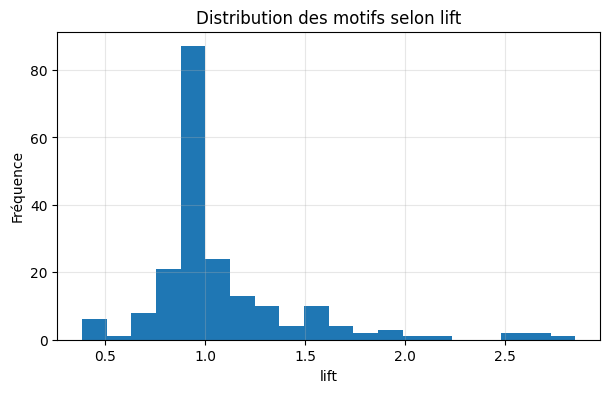


--- Fin du Pipeline (Échantillonnage en Sortie) ---
Note: Les étapes interactives (Scoring, Feedback) ne s'appliquent pas
à ce pipeline car il ne génère pas de pool exhaustif.


In [14]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
import warnings
warnings.filterwarnings('ignore')

# --- 1. Pré-traitement (Commun aux deux pipelines) ---
print("Pré-traitement des données...")
transactions = pd.read_csv('sample_transactions.csv', header=None)
transactions.drop([0], inplace=True)
transactions = transactions.groupby(0)[1].apply(lambda x: ' '.join(x)).reset_index()
transactions.drop(0, axis=1, inplace=True)
transactions_list = transactions[1].apply(lambda x: x.split()).tolist()
te = TransactionEncoder()
te_ary = te.fit(transactions_list).transform(transactions_list)
df = pd.DataFrame(te_ary, columns=te.columns_)
print(f"Dataset binarisé : {df.shape[0]} transactions, {df.shape[1]} items")


# --- 2. CHOIX DU PIPELINE ---
# Modifiez cette variable pour tester les deux approches
PIPELINE_CHOICE = 'output_sampling'  # Options: 'exhaustive' ou 'output_sampling'

if PIPELINE_CHOICE == 'exhaustive':
    # --- 3A. PIPELINE EXHAUSTIF (Steps 1, 2, 4) ---
    print("\n--- Lancement du Pipeline Interactif (Exhaustif + Scoring) ---")
    # === Step 1: Génération du pool (de Cellule 15 & 16) ===
    print("Étape 1: Génération du pool Apriori...")
    MIN_SUPPORT = 0.005 
    frequent_itemsets = apriori(df, min_support=MIN_SUPPORT, use_colnames=True)
    frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
    print(f"Pool P : {len(frequent_itemsets)} motifs extraits avec min_support={MIN_SUPPORT}")
    print(f"Distribution des longueurs :")
    print(frequent_itemsets['length'].value_counts().sort_index())

    print("="*70)
    print("POOL DE CANDIDATS P - Métriques complètes")
    print("="*70)
    print(f"\nNombre total de motifs : {len(pool_P)}")
    print(f"Support moyen : {pool_P['support'].mean():.4f}")
    print(f"Coverage moyenne : {pool_P['coverage'].mean():.4f}")
    print(f"Longueur moyenne : {pool_P['length'].mean():.2f}")
    print("\n--- Top 10 motifs par support ---")
    top_support = pool_P.nlargest(10, 'support')[['itemset', 'support', 'coverage', 'length']]
    print(top_support.to_string(index=False))
    print("\n--- Top 10 motifs par confidence ---")
    top_conf = pool_P[pool_P['length'] > 1].nlargest(10, 'confidence')[
        ['itemset', 'confidence', 'lift', 'support', 'length']
    ]
    print(top_conf.to_string(index=False))
    print("\n--- Top 10 motifs par lift ---")
    top_lift = pool_P[pool_P['length'] > 1].nlargest(10, 'lift')[
        ['itemset', 'lift', 'confidence', 'support', 'length']
    ]
    print(top_lift.to_string(index=False))
    print("\n--- Statistiques descriptives ---")
    print(pool_P[['support', 'coverage', 'confidence', 'lift', 'length']].describe())
    pool_P.to_csv('pool_P_candidats.csv', index=False)
    print("\n✅ Pool P sauvegardé dans 'pool_P_candidats.csv'")

    # === Step 2 & 4: Session interactive et Évaluation (de Cellule 21 & 22) ===
    print("\nÉtape 2 & 4: Lancement de la session interactive et évaluation...")
    ipm = InteractivePatternMining('pool_P_candidats.csv') 
    print("\n🔍 SESSION 1 : Stratégie Balanced")
    ipm.start_session(strategy='balanced', method='importance', k=10)
    ipm.feedback(0, 'like') # Simule un feedback
    ipm.feedback(5, 'dislike') # Simule un feedback
    ipm.resample(k=10) 
    print("\n📊 COMPARAISON DES STRATÉGIES")
    ipm.compare_strategies(k=10)
    print("\n📈 ÉVALUATION GLOBALE (Pipeline Exhaustif)")
    evaluator = PatternEvaluator(ipm.sampler, ipm.pool_P) 
    eval_results = evaluator.evaluate(df)
    print(eval_results)

elif PIPELINE_CHOICE == 'output_sampling':
    # --- 3B. PIPELINE ALTERNATIF (Step 5) ---
    print("\n--- Lancement du Pipeline (Échantillonnage en Sortie) ---")
    print("Étape 5: Échantillonnage en sortie (basé sur 'lift')")
    out_sampler = OutputPatternSampler(df, measure='lift', n_samples=1000, max_length=3) 
    sampled_motifs = out_sampler.generate_sample()
    print(f"\nNombre de motifs échantillonnés : {len(sampled_motifs)}")
    print(sampled_motifs.head(10))
    # Afficher la distribution des motifs
    print("\nAffichage de la distribution de la mesure d'intérêt ('lift')")
    out_sampler.plot_distribution(sampled_motifs)
    print("\n--- Fin du Pipeline (Échantillonnage en Sortie) ---")
    print("Note: Les étapes interactives (Scoring, Feedback) ne s'appliquent pas")
    print("à ce pipeline car il ne génère pas de pool exhaustif.")

else:
    print(f"Erreur : Choix de pipeline '{PIPELINE_CHOICE}' non reconnu.")